# Credit Scoring Model

**CodeAlpha Machine Learning Internship Project**

### Objective
Build an end-to-end classification system that predicts an applicant's creditworthiness from the columns available in the selected dataset.

> **Important:** This notebook does not assume fixed column names and does not fabricate results. Run the data-inspection cells first, then set the target column based on the actual dataset.


## 1. What, Why, How

**What:** Import the libraries needed for data analysis, visualization, preprocessing, model training, and evaluation.

**Why:** These libraries provide the standard tools for a complete machine-learning workflow.

**How:** Pandas/NumPy handle data, Matplotlib/Seaborn create visualizations, and Scikit-learn provides preprocessing, models, metrics, and tuning.


In [7]:
# Install if needed in Google Colab:
# !pip install -q pandas numpy matplotlib seaborn scikit-learn joblib

import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42


## 2. Load the Dataset

Replace `DATA_PATH` with the actual CSV path.

The next cells inspect the real dataset before any assumptions are made.


In [12]:

import pandas as pd
import numpy as np

file_path = "/credit_risk_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 3. Data Understanding

Check missing values, duplicates, unique values, and the distribution of candidate target columns.

**Why:** A credit-scoring project must first understand what information is actually present. Column names and target meaning vary across datasets.


In [13]:
print("Missing values:")
missing = df.isnull().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame("missing_count"))

print("Duplicate rows:", df.duplicated().sum())

print("\nUnique values per column:")
display(df.nunique().sort_values().to_frame("unique_values"))


Missing values:


,missing_count
loan_int_rate,3116
person_emp_length,895


Duplicate rows: 165

Unique values per column:


,unique_values
cb_person_default_on_file,2
loan_status,2
person_home_ownership,4
loan_intent,6
loan_grade,7
cb_person_cred_hist_length,29
person_emp_length,36
person_age,58
loan_percent_income,77
loan_int_rate,348


## 4. Identify the Target

Set `TARGET_COLUMN` **after inspecting the printed column list**.

Do not invent a target column. The target must be the actual credit-risk/creditworthiness label in the selected dataset.


In [14]:
df.info()
df.isnull().sum()
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


## 5. Basic Cleaning

**What:** Remove exact duplicate records and standardize obviously incorrect data types only when the actual dataset requires it.

**Why:** Duplicate records can distort model evaluation. Incorrect types can prevent numerical/categorical preprocessing from working correctly.

No automatic outlier deletion is performed because an extreme financial value may be a legitimate applicant record.


In [15]:
before = len(df)
df = df.drop_duplicates().copy()
print(f"Removed {before - len(df)} duplicate rows.")

# Strip whitespace from string column names.
df.columns = df.columns.astype(str).str.strip()

# Show object columns so that any required type conversion can be decided from the data.
object_columns = df.select_dtypes(include=["object", "string"]).columns.tolist()
print("Categorical/text columns:", object_columns)


Removed 165 duplicate rows.
Categorical/text columns: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


## 6. Exploratory Data Analysis

The following visualizations are generated from the actual columns in the dataset. The code avoids assuming that income/debt/payment-history columns exist.

If a feature is available, you can add a targeted plot after inspecting the column names.


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/credit_risk_dataset.csv")

# Display basic information
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns)

# Display first 5 rows
df.head()

Dataset Shape: (32581, 12)

Column Names:
Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [18]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [19]:
print(df['loan_status'].value_counts())

loan_status
0    25473
1     7108
Name: count, dtype: int64


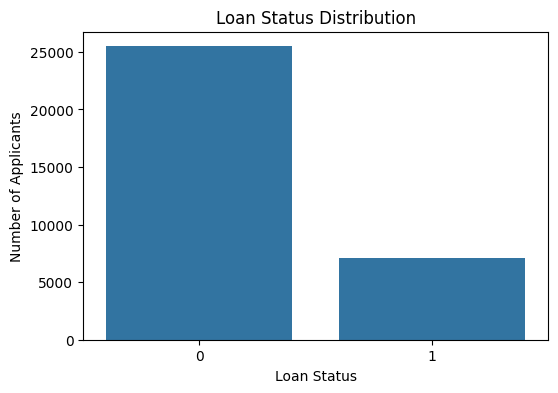

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(x='loan_status', data=df)

plt.title('Loan Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Number of Applicants')
plt.show()

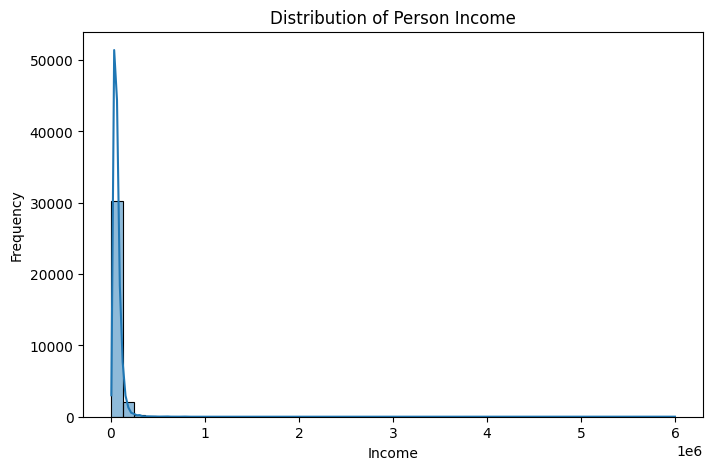

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(df['person_income'], bins=50, kde=True)

plt.title('Distribution of Person Income')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

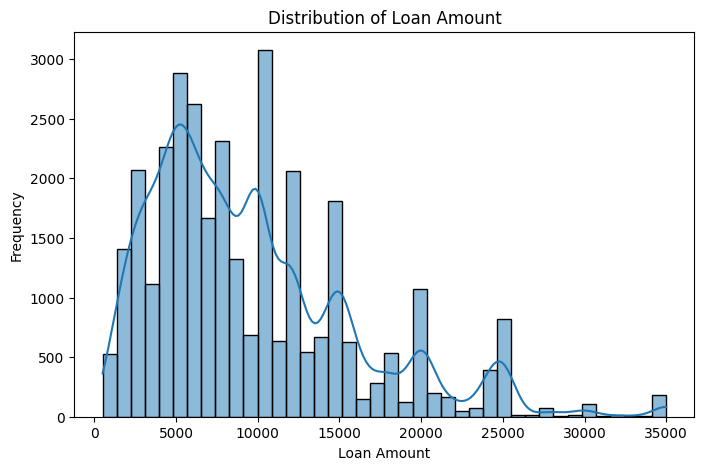

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(df['loan_amnt'], bins=40, kde=True)

plt.title('Distribution of Loan Amount')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()

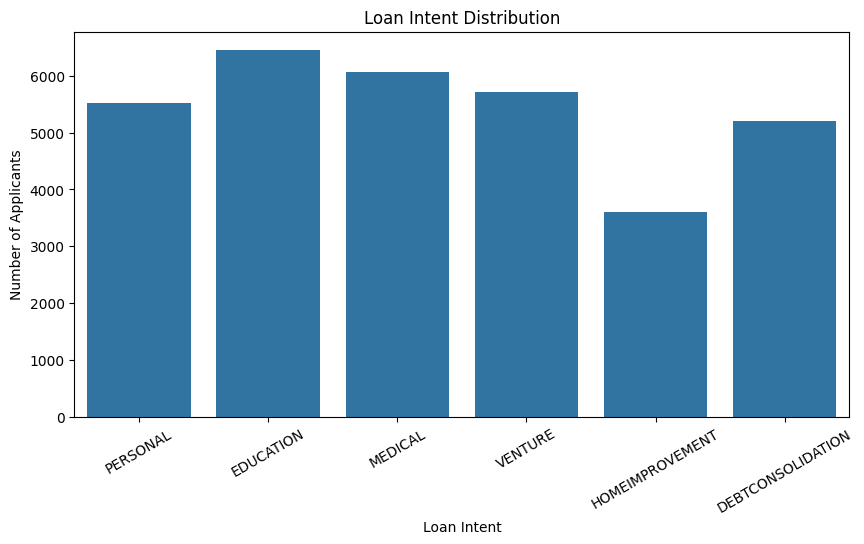

In [23]:
plt.figure(figsize=(10,5))

sns.countplot(x='loan_intent', data=df)

plt.title('Loan Intent Distribution')
plt.xlabel('Loan Intent')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=30)
plt.show()

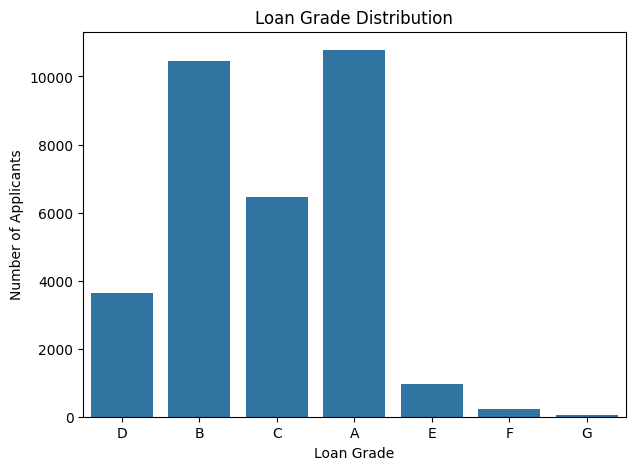

In [24]:
plt.figure(figsize=(7,5))

sns.countplot(x='loan_grade', data=df)

plt.title('Loan Grade Distribution')
plt.xlabel('Loan Grade')
plt.ylabel('Number of Applicants')
plt.show()

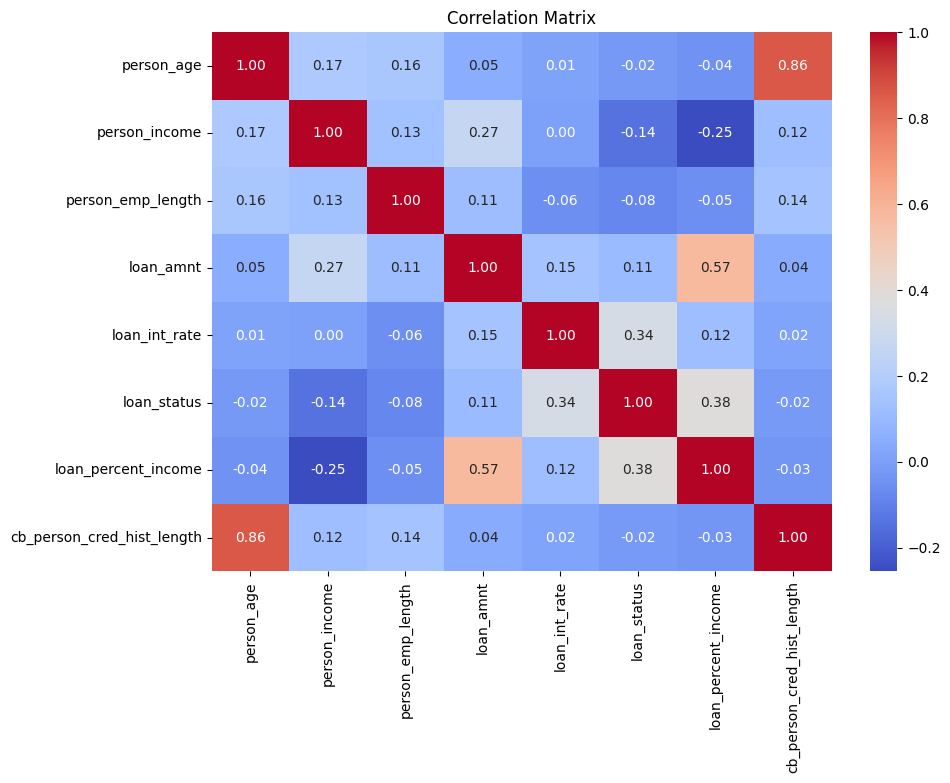

In [25]:
plt.figure(figsize=(10,7))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

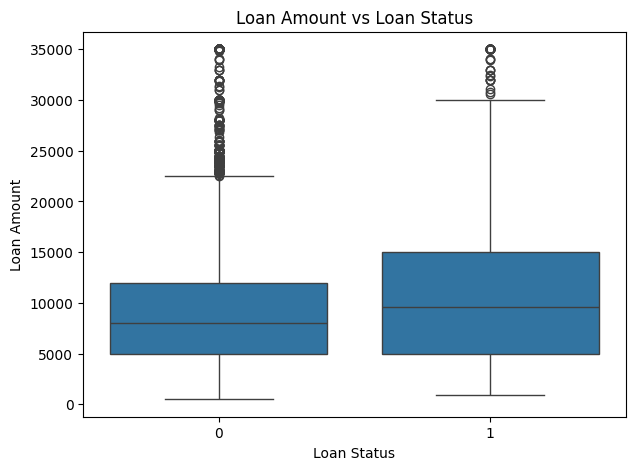

In [26]:
plt.figure(figsize=(7,5))

sns.boxplot(x='loan_status', y='loan_amnt', data=df)

plt.title('Loan Amount vs Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Loan Amount')
plt.show()

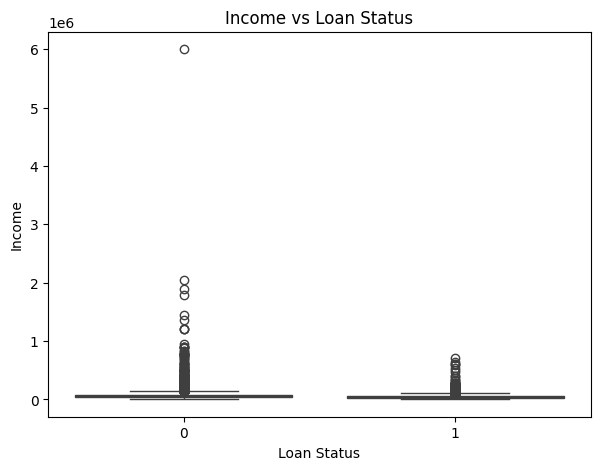

In [27]:
plt.figure(figsize=(7,5))

sns.boxplot(x='loan_status', y='person_income', data=df)

plt.title('Income vs Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Income')
plt.show()

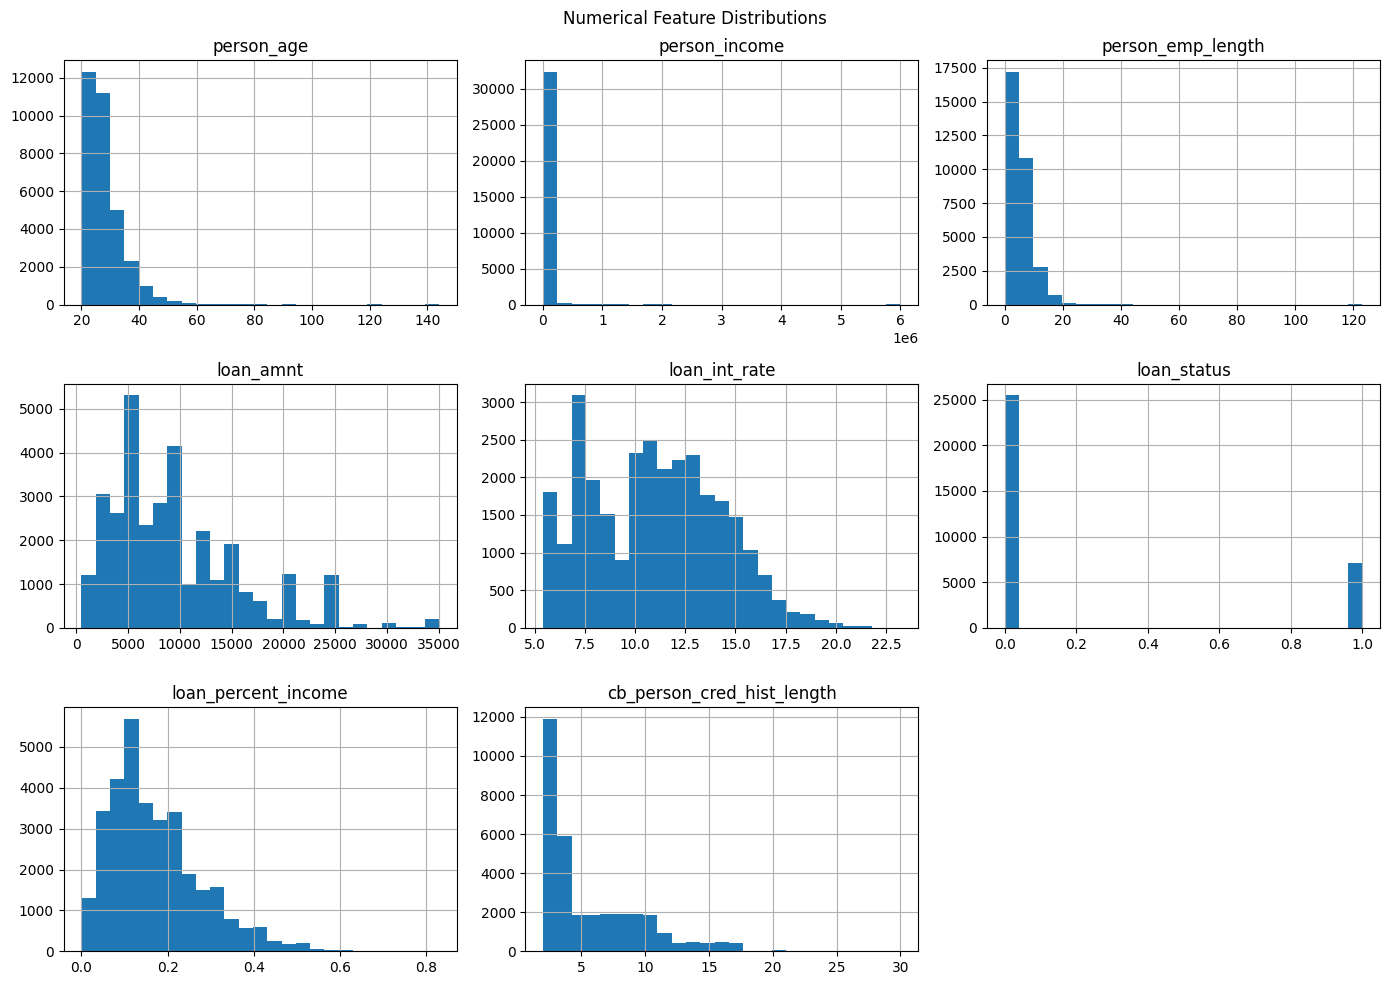

In [28]:
# Numerical distributions
numeric_for_eda = df.select_dtypes(include=np.number).columns.tolist()

if numeric_for_eda:
    df[numeric_for_eda].hist(figsize=(14, 10), bins=25)
    plt.suptitle("Numerical Feature Distributions")
    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


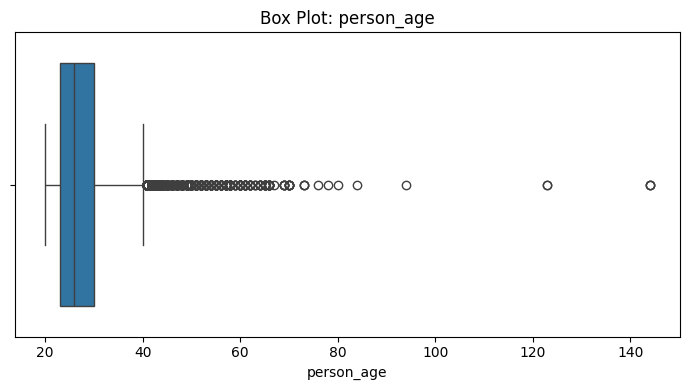

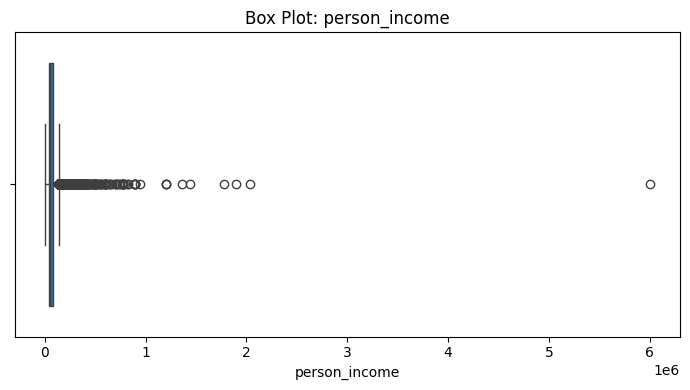

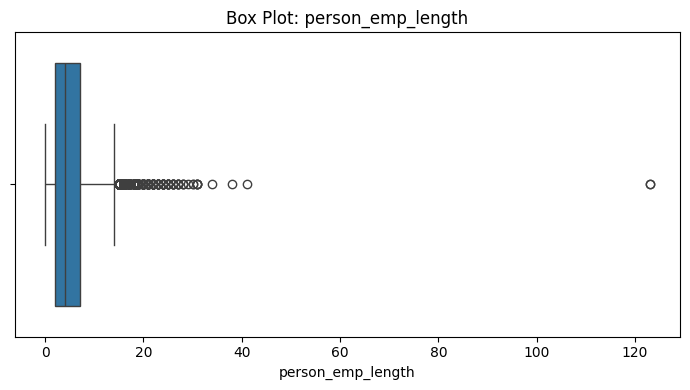

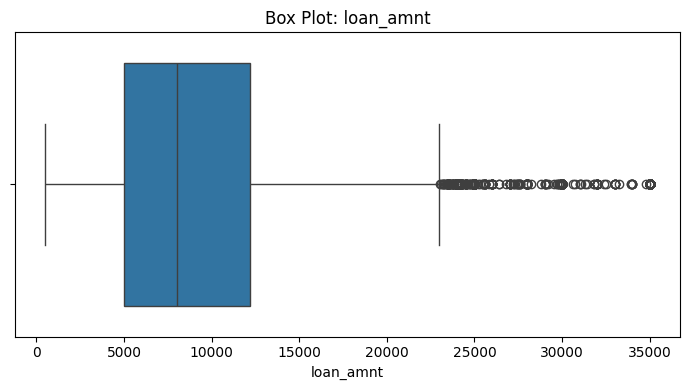

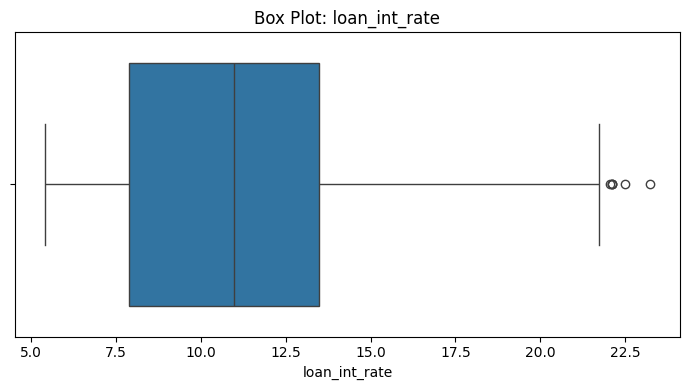

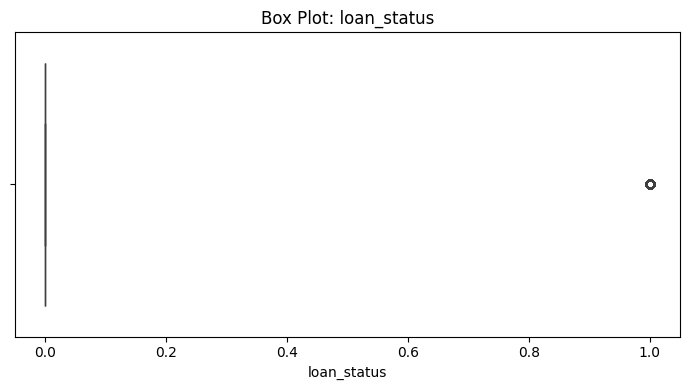

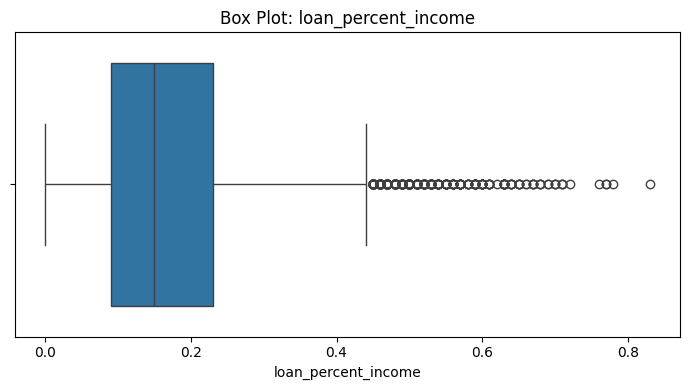

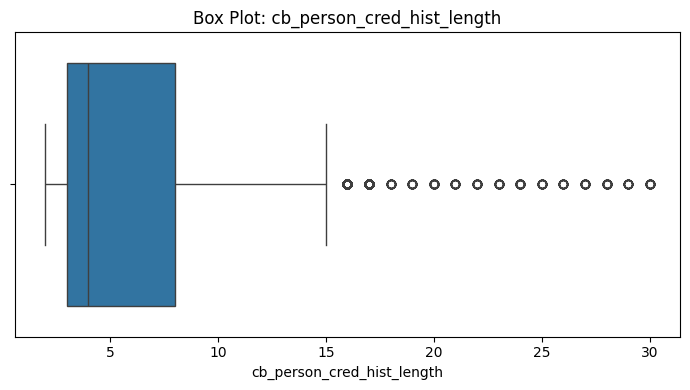

In [29]:
# Box plots for numerical variables
for col in numeric_for_eda:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot: {col}")
    plt.tight_layout()
    plt.show()


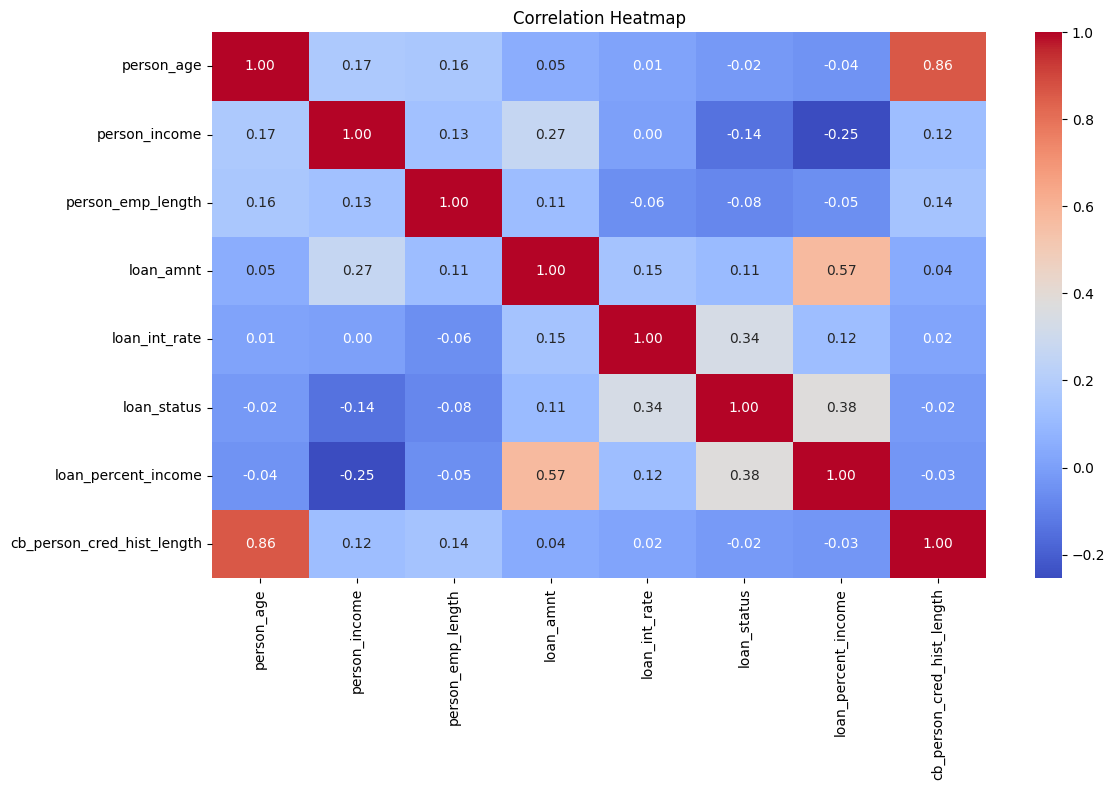

In [30]:
# Correlation heatmap
if len(numeric_for_eda) >= 2:
    plt.figure(figsize=(12, 8))
    sns.heatmap(df[numeric_for_eda].corr(), annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for a correlation heatmap.")


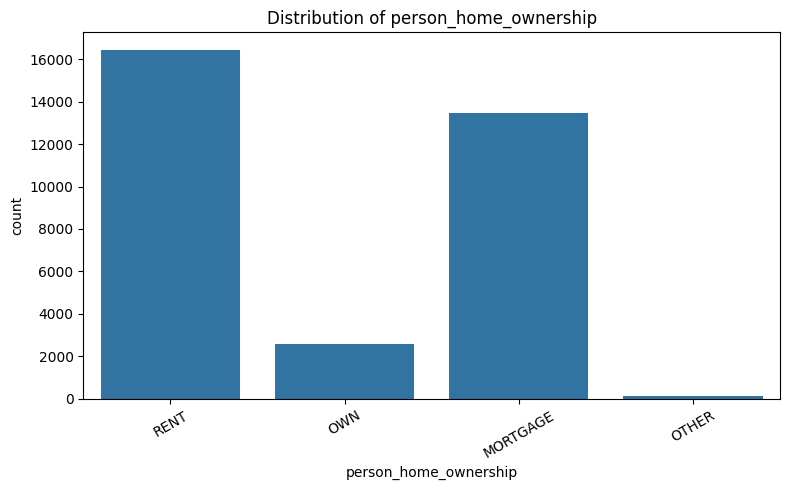

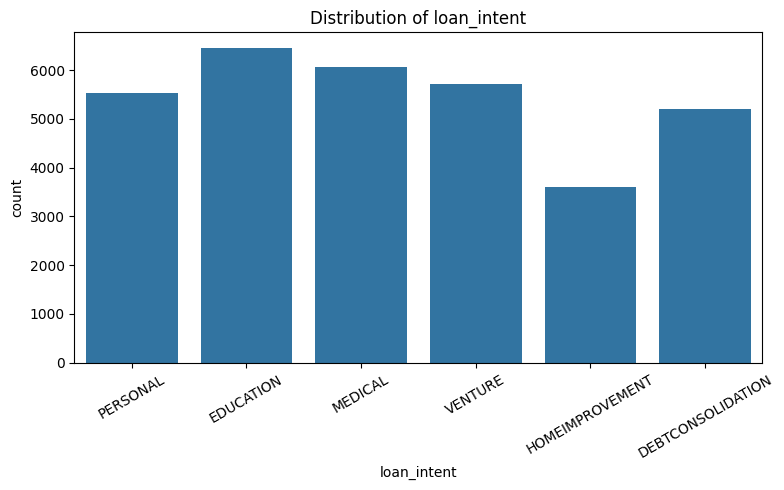

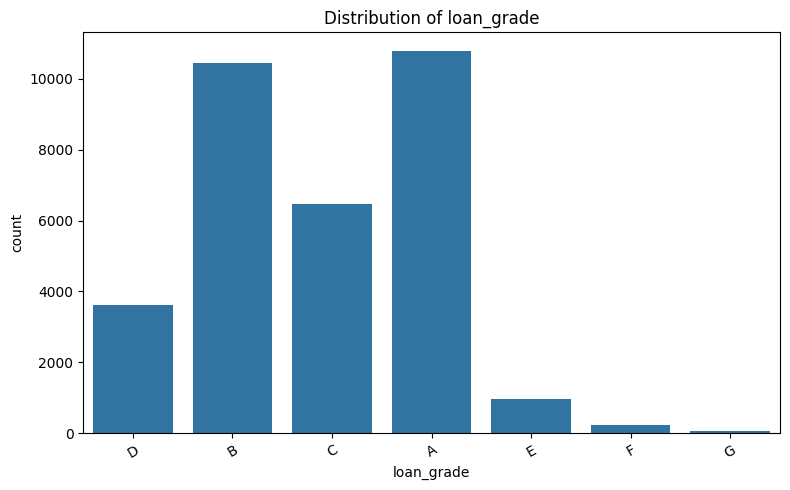

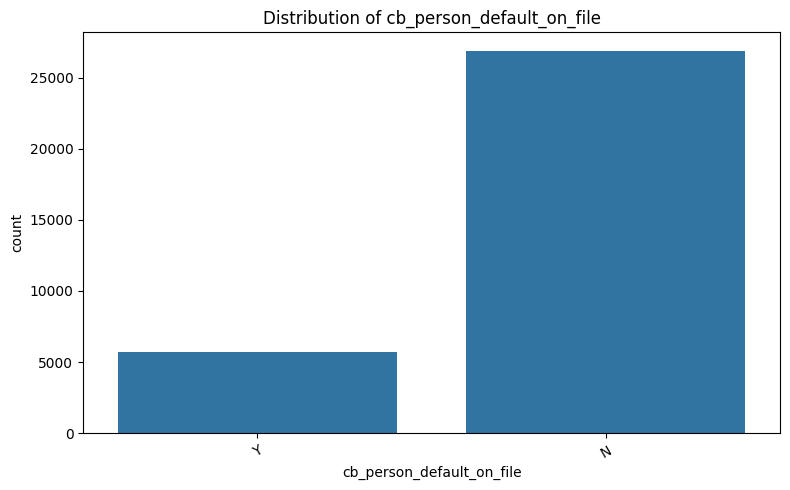

In [31]:
# Categorical feature distributions
categorical_for_eda = df.select_dtypes(include=["object", "category"]).columns.tolist()

for col in categorical_for_eda:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

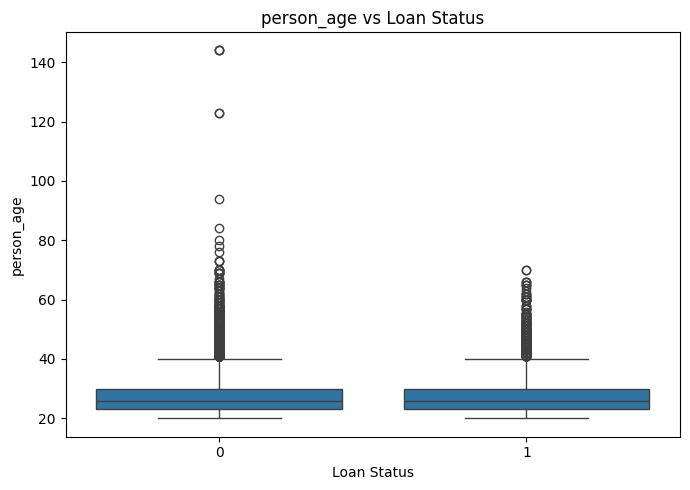

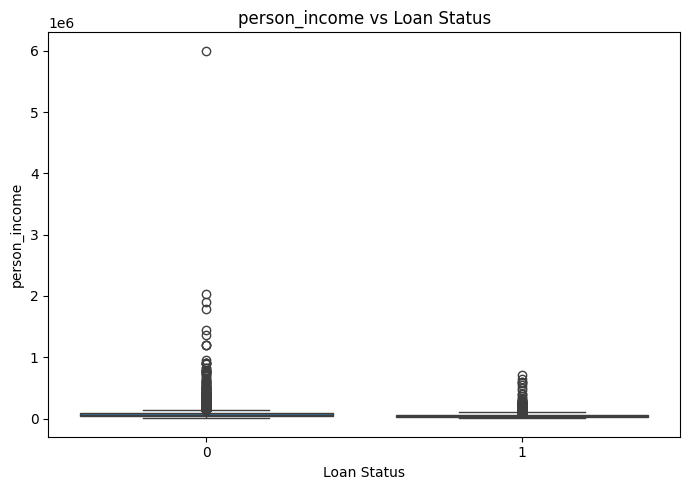

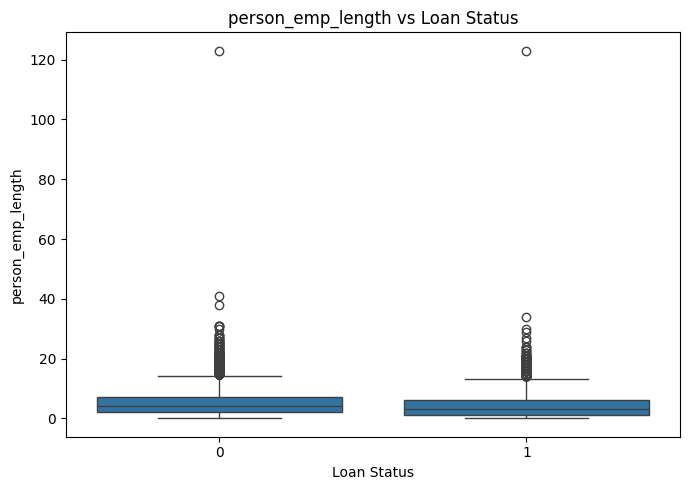

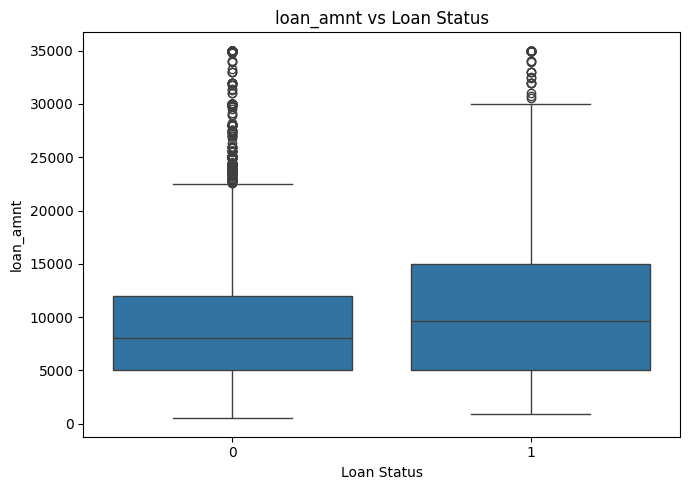

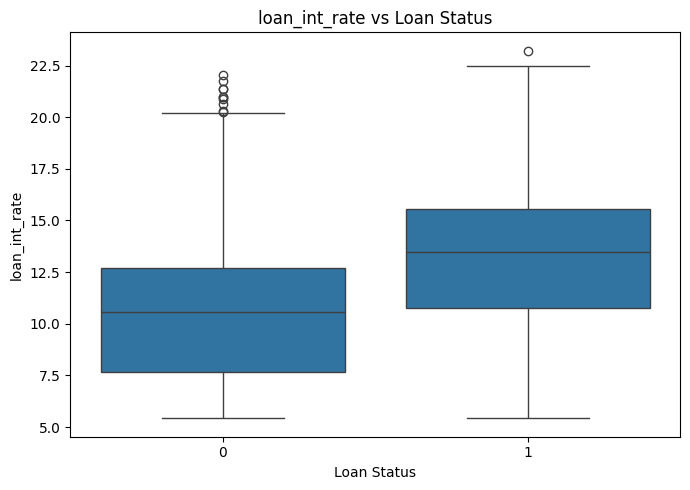

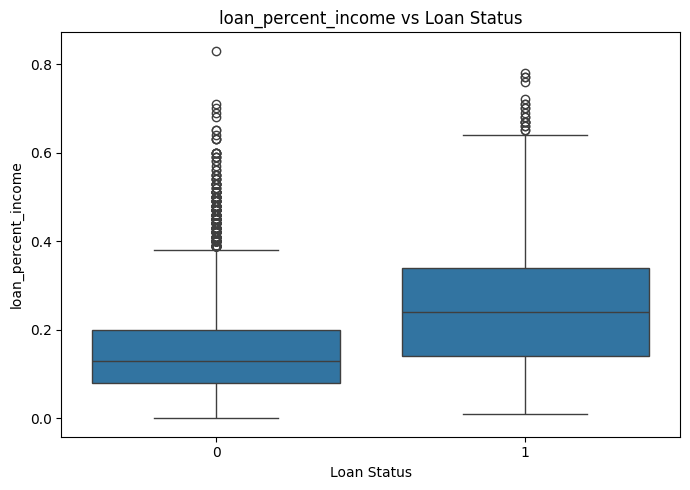

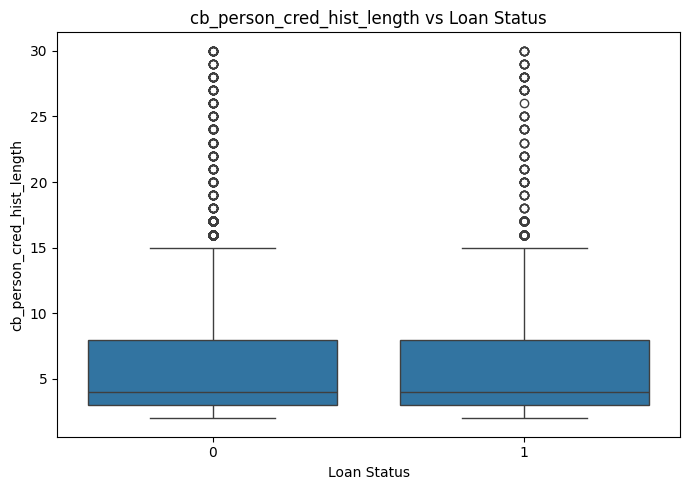

In [32]:
# Numerical features vs Loan Status

for col in numeric_for_eda:
    if col != "loan_status":
        plt.figure(figsize=(7, 5))
        sns.boxplot(data=df, x="loan_status", y=col)
        plt.title(f"{col} vs Loan Status")
        plt.xlabel("Loan Status")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()

## 7. Optional Feature Engineering

Create only features supported by the real dataset.

For example, if the dataset has an income and debt column, a debt-to-income ratio may be useful. The exact column names must be confirmed first.


New feature created: loan_to_income_ratio


,person_income,loan_amnt,loan_to_income_ratio
0,59000,35000,0.593220
1,9600,1000,0.104167
2,9600,5500,0.572917
3,65500,35000,0.534351
4,54400,35000,0.643382


Loan-to-Income Ratio statistics:


,loan_to_income_ratio
count,32581.000000
mean,0.170553
std,0.107049
min,0.000789
25%,0.089655
50%,0.148148
75%,0.229167
max,0.830000


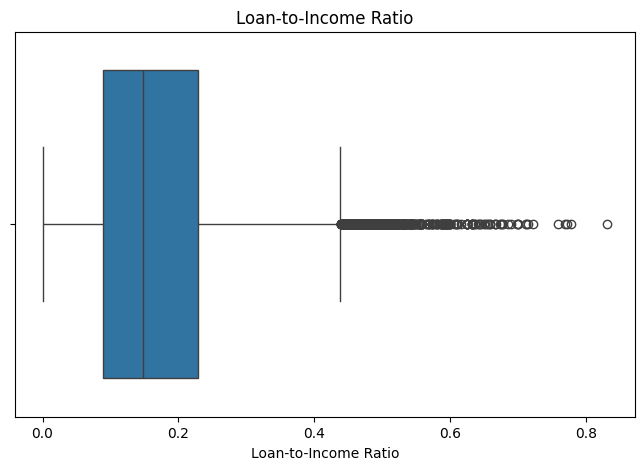

Missing values:
0

Infinite values:
0


In [33]:
# Example: activate only after confirming the real column names.
# INCOME_COLUMN = "actual_income_column"
# DEBT_COLUMN = "actual_debt_column"
#
# if INCOME_COLUMN in df.columns and DEBT_COLUMN in df.columns:
#     df["Debt_to_Income_Ratio"] = (
#         df[DEBT_COLUMN] / df[INCOME_COLUMN].replace(0, np.nan)
#     )
#     df["Debt_to_Income_Ratio"] = df["Debt_to_Income_Ratio"].replace(
#         [np.inf, -np.inf], np.nan
#     )
#
# print(df[["Debt_to_Income_Ratio"]].describe())
df["loan_to_income_ratio"] = (
    df["loan_amnt"] / df["person_income"].replace(0, np.nan)
)

# Check the new feature
print("New feature created: loan_to_income_ratio")

display(df[[
    "person_income",
    "loan_amnt",
    "loan_to_income_ratio"
]].head())
# Statistical summary of the new feature

print("Loan-to-Income Ratio statistics:")
display(df["loan_to_income_ratio"].describe())
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["loan_to_income_ratio"])

plt.title("Loan-to-Income Ratio")
plt.xlabel("Loan-to-Income Ratio")

plt.show()
print("Missing values:")
print(df["loan_to_income_ratio"].isnull().sum())

print("\nInfinite values:")
print(np.isinf(df["loan_to_income_ratio"]).sum())



## 8. Prepare X and y

`X` contains the applicant features and `y` contains the target.

The target must be encoded into classification labels if it is not already numeric.


In [34]:
# Step 8: Prepare X and y

# Target variable
TARGET_COLUMN = "loan_status"

# X = input features
X = df.drop(columns=[TARGET_COLUMN]).copy()

# y = target variable
y = df[TARGET_COLUMN].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("Target values:")
print(y.unique())


X shape: (32581, 12)
y shape: (32581,)
Target values:
[1 0]


### Target encoding

For a binary target, map the actual two classes to 0 and 1. The mapping below is intentionally not automatic because the meaning of each class must be verified from the dataset documentation.

If the target is already 0/1, the code keeps it as-is.


In [35]:
TARGET_COLUMN = "loan_status"

X = df.drop(columns=[TARGET_COLUMN]).copy()
y = df[TARGET_COLUMN].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("Target values:")
print(y.unique())
# Check target distribution

print("Target distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print(y.value_counts(normalize=True) * 100)


X shape: (32581, 12)
y shape: (32581,)
Target values:
[1 0]
Target distribution:
loan_status
0    25473
1     7108
Name: count, dtype: int64

Target percentage:
loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64


## 9. Train/Test Split

Use 80% of the data for training and 20% for testing. Stratification keeps the class proportions similar when possible.

The test set is kept unseen until final evaluation.


In [36]:
# Step 9: Train/Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (26064, 12)
Testing data: (6517, 12)


## 10. Preprocessing Pipeline

**Numerical:** median imputation + scaling.

**Categorical:** most-frequent imputation + one-hot encoding.

`ColumnTransformer` and `Pipeline` ensure transformations are learned only from training data, reducing data leakage.


In [37]:
# Step 10: Preprocessing Pipeline

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Identify numerical and categorical columns
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


# Numerical preprocessing
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# Categorical preprocessing
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


# Combine both pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

print("\nPreprocessing pipeline created successfully!")

Numerical features:
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'loan_to_income_ratio']

Categorical features:
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

Preprocessing pipeline created successfully!


## 11. Train Three Classification Models

Models required by the project:

1. Logistic Regression
2. Decision Tree
3. Random Forest


In [38]:

# Step 11: Train Three Classification Models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

RANDOM_STATE = 42

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

trained_pipelines = {}
results = []

for name, model in models.items():
    print(f"Training: {name}")

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    trained_pipelines[name] = pipeline

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred, average="weighted", zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred, average="weighted", zero_division=0
        ),
        "F1-Score": f1_score(
            y_test, y_pred, average="weighted", zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).sort_values(
    by="ROC-AUC", ascending=False
).reset_index(drop=True)

print("\nAll models trained successfully.")
display(results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-Score": "{:.4f}",
    "ROC-AUC": "{:.4f}"
}))


Training: Logistic Regression
Training: Decision Tree
Training: Random Forest

All models trained successfully.


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.9342,0.9367,0.9342,0.9304,0.9307
1,Logistic Regression,0.8716,0.8652,0.8716,0.8643,0.8766
2,Decision Tree,0.8901,0.8927,0.8901,0.8912,0.8494


## 12. Detailed Evaluation

Accuracy alone is not enough for credit scoring. Precision, recall, F1-score, and ROC-AUC are reported as required by the project.

False positives and false negatives can have different consequences, so inspect the confusion matrix rather than relying on one metric.


Logistic Regression
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      5095
           1       0.78      0.58      0.66      1422

    accuracy                           0.87      6517
   macro avg       0.83      0.77      0.79      6517
weighted avg       0.87      0.87      0.86      6517

Accuracy: 0.8716
Precision: 0.8652
Recall: 0.8716
F1-Score: 0.8643
ROC-AUC: 0.8766


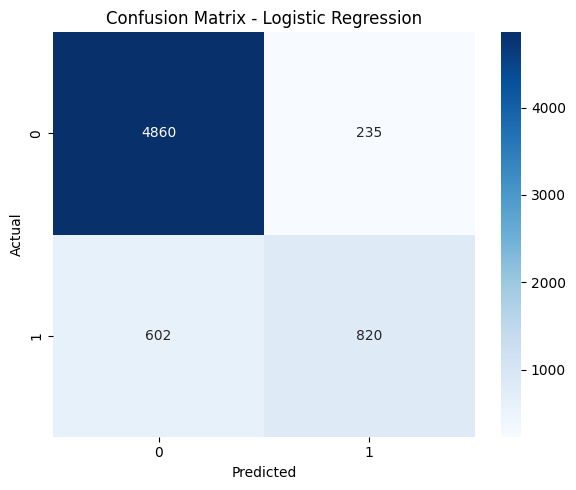

Decision Tree
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      5095
           1       0.73      0.78      0.76      1422

    accuracy                           0.89      6517
   macro avg       0.84      0.85      0.84      6517
weighted avg       0.89      0.89      0.89      6517

Accuracy: 0.8901
Precision: 0.8927
Recall: 0.8901
F1-Score: 0.8912
ROC-AUC: 0.8494


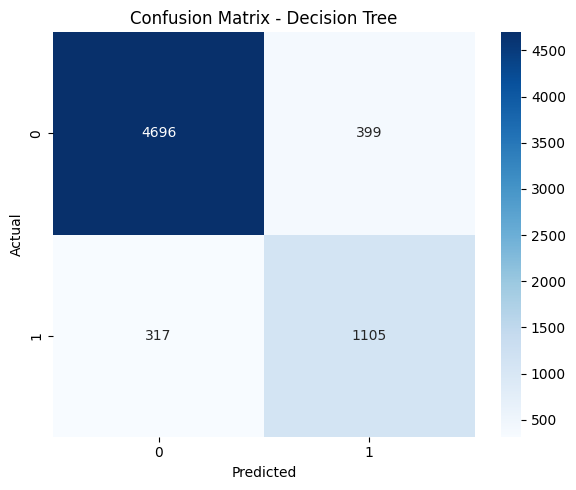

Random Forest
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       0.97      0.72      0.83      1422

    accuracy                           0.93      6517
   macro avg       0.95      0.86      0.89      6517
weighted avg       0.94      0.93      0.93      6517

Accuracy: 0.9342
Precision: 0.9367
Recall: 0.9342
F1-Score: 0.9304
ROC-AUC: 0.9307


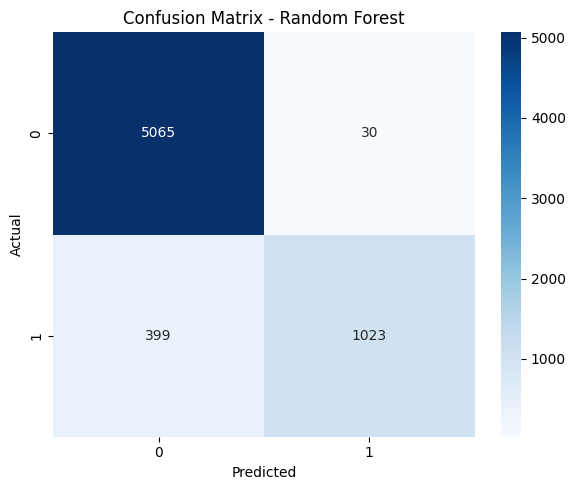

In [39]:

# Step 12: Detailed Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

for name, pipeline in trained_pipelines.items():
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    print("=" * 70)
    print(name)
    print("=" * 70)

    print(classification_report(
        y_test,
        y_pred,
        zero_division=0
    ))

    print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
    print("Precision:", round(
        precision_score(y_test, y_pred, average="weighted", zero_division=0), 4
    ))
    print("Recall:", round(
        recall_score(y_test, y_pred, average="weighted", zero_division=0), 4
    ))
    print("F1-Score:", round(
        f1_score(y_test, y_pred, average="weighted", zero_division=0), 4
    ))
    print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


## 13. ROC Curves

A ROC curve compares the true-positive rate with the false-positive rate across thresholds. AUC summarizes this ranking ability in a single value.


<Figure size 800x600 with 0 Axes>

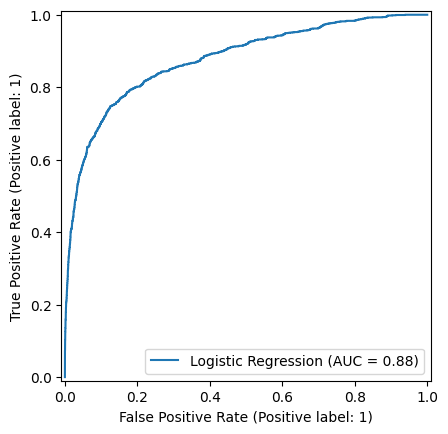

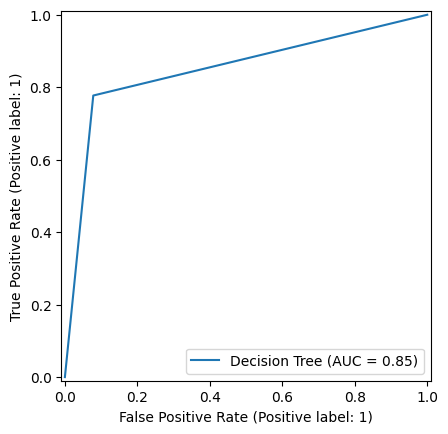

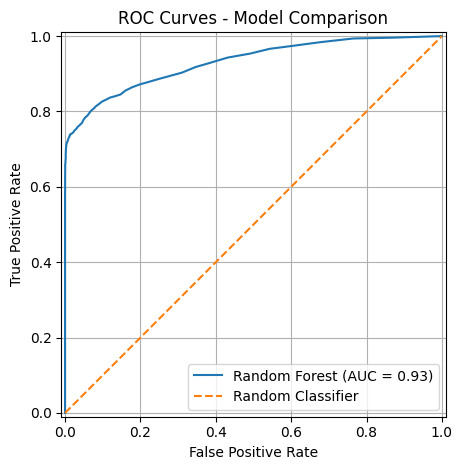

In [40]:
# ============================================
# STEP 13: ROC CURVES
# ============================================

import matplotlib.pyplot as plt

from sklearn.metrics import RocCurveDisplay

# Create ROC curve plot
plt.figure(figsize=(8, 6))

# Plot ROC curve for each trained model
for name, pipeline in trained_pipelines.items():

    # Get probability of default (class 1)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Plot ROC curve
    RocCurveDisplay.from_predictions(
        y_test,
        y_prob,
        name=name
    )

# Add reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curves - Model Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## 14. Model Comparison


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.9342,0.9367,0.9342,0.9304,0.9307
1,Logistic Regression,0.8716,0.8652,0.8716,0.8643,0.8766
2,Decision Tree,0.8901,0.8927,0.8901,0.8912,0.8494


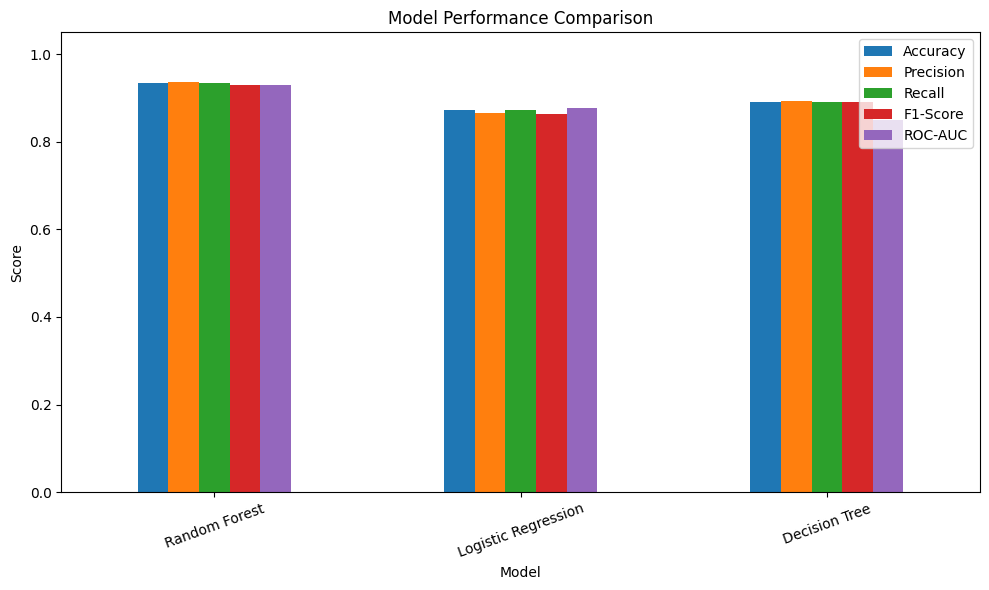

In [41]:

# Step 13: Model Performance Comparison

if "results_df" not in globals() or results_df.empty:
    raise ValueError(
        "results_df is missing. Run the model-training cell first."
    )

display(results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-Score": "{:.4f}",
    "ROC-AUC": "{:.4f}"
}))

plot_df = results_df.set_index("Model")

plot_df.plot(kind="bar", figsize=(10, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### Duplicate setup removed

The required imports are already included in the earlier notebook cells.


### Duplicate train/test split removed

`X_train`, `X_test`, `y_train`, and `y_test` are created in Step 9 above.


### Duplicate preprocessing removed

The preprocessing pipeline is created in Step 10 above.


### Duplicate model definitions removed

The models and trained pipelines are created in Step 11 above.


## 15. Select the Best Model

This notebook selects the model using the **highest ROC-AUC** rather than assuming that Random Forest must win.

For a real credit-scoring application, the metric used for final selection should also reflect the business cost of false positives and false negatives.


In [42]:

# Step 14: Select the model with the highest ROC-AUC

if results_df.empty:
    raise ValueError("No model results available.")

best_model_name = results_df.loc[0, "Model"]
best_pipeline = trained_pipelines[best_model_name]

print("Selected model by ROC-AUC:", best_model_name)
display(results_df.iloc[[0]])


Selected model by ROC-AUC: Random Forest


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.934172,0.936694,0.934172,0.930415,0.930655


## 16. Hyperparameter Tuning

Tune the selected model with cross-validation.

The parameter grid is chosen according to the model type. `GridSearchCV` evaluates combinations using cross-validation on the training data.


In [43]:

# Step 15: Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

if best_model_name == "Random Forest":
    param_grid = {
        "model__n_estimators": [100, 200],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2]
    }
elif best_model_name == "Decision Tree":
    param_grid = {
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    }
else:
    param_grid = {
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__solver": ["liblinear"]
    }

grid_search = GridSearchCV(
    estimator=best_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    refit=True
)

grid_search.fit(X_train, y_train)
tuned_model = grid_search.best_estimator_

print("Best parameters:")
print(grid_search.best_params_)
print("\nBest cross-validation ROC-AUC:", round(grid_search.best_score_, 4))


Best parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best cross-validation ROC-AUC: 0.933


## 17. Final Model Evaluation

Evaluate the tuned pipeline once on the untouched test set. These are the final test-set results and should be reported exactly as calculated.


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,0.9339,0.9363,0.9339,0.9301,0.9319


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       0.97      0.72      0.83      1422

    accuracy                           0.93      6517
   macro avg       0.95      0.86      0.89      6517
weighted avg       0.94      0.93      0.93      6517



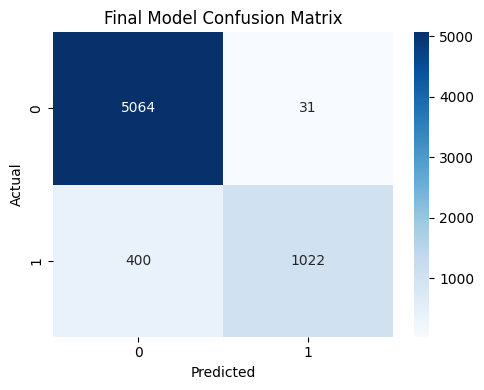

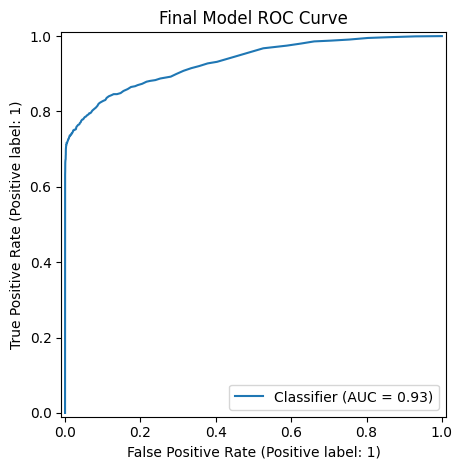

In [44]:

# Step 16: Final Model Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

final_pred = tuned_model.predict(X_test)
final_prob = tuned_model.predict_proba(X_test)[:, 1]

final_metrics = {
    "Accuracy": accuracy_score(y_test, final_pred),
    "Precision": precision_score(
        y_test, final_pred, average="weighted", zero_division=0
    ),
    "Recall": recall_score(
        y_test, final_pred, average="weighted", zero_division=0
    ),
    "F1-Score": f1_score(
        y_test, final_pred, average="weighted", zero_division=0
    ),
    "ROC-AUC": roc_auc_score(y_test, final_prob)
}

final_metrics_df = pd.DataFrame([final_metrics])
display(final_metrics_df.style.format("{:.4f}"))

print("Classification Report:")
print(classification_report(y_test, final_pred, zero_division=0))

cm = confusion_matrix(y_test, final_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

RocCurveDisplay.from_predictions(y_test, final_prob)
plt.title("Final Model ROC Curve")
plt.tight_layout()
plt.show()


## 18. Feature Importance

Feature importance is reported only when the final estimator exposes `feature_importances_`.

Because preprocessing can expand categorical variables into multiple one-hot columns, the code obtains the transformed feature names from the fitted `ColumnTransformer`.

Feature importance indicates model usage/association; it does **not** prove causation.


,Feature,Importance
7,num__loan_to_income_ratio,0.162753
5,num__loan_percent_income,0.125129
1,num__person_income,0.116047
4,num__loan_int_rate,0.100085
11,cat__person_home_ownership_RENT,0.061098
21,cat__loan_grade_D,0.056085
3,num__loan_amnt,0.056037
2,num__person_emp_length,0.055239
0,num__person_age,0.039159
8,cat__person_home_ownership_MORTGAGE,0.030842


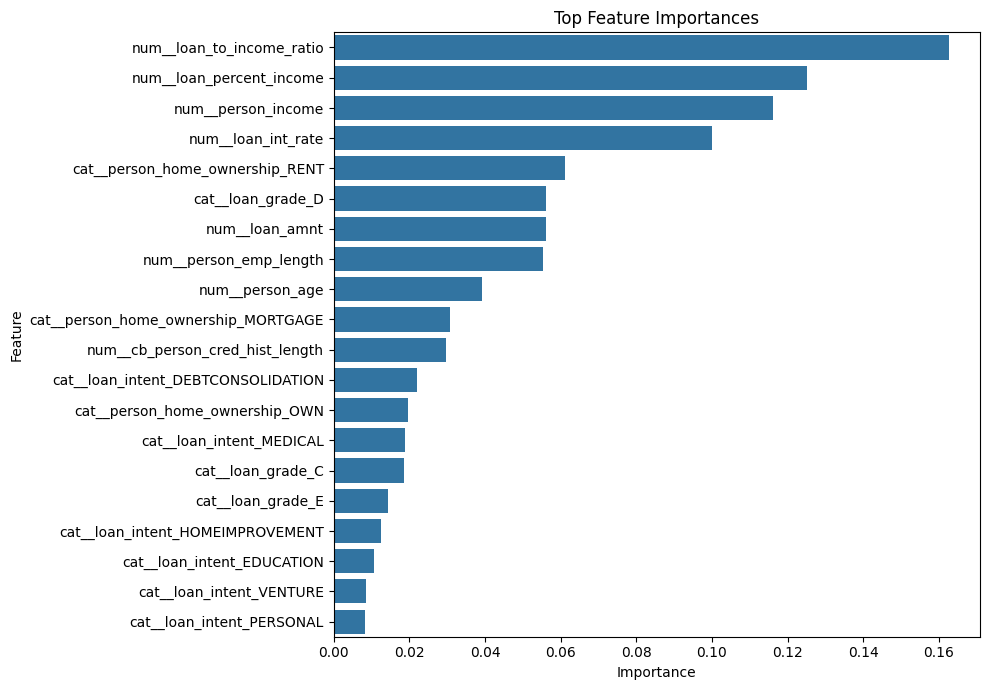

In [45]:

# Step 17: Feature Importance

final_estimator = tuned_model.named_steps["model"]
fitted_preprocessor = tuned_model.named_steps["preprocessor"]

feature_names = fitted_preprocessor.get_feature_names_out()

if hasattr(final_estimator, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": final_estimator.feature_importances_
    }).sort_values(
        "Importance", ascending=False
    ).head(20)

    display(importance_df)

    plt.figure(figsize=(10, 7))
    sns.barplot(data=importance_df, x="Importance", y="Feature")
    plt.title("Top Feature Importances")
    plt.tight_layout()
    plt.show()
elif hasattr(final_estimator, "coef_"):
    coefficient_values = final_estimator.coef_[0]

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefficient_values,
        "Absolute Importance": np.abs(coefficient_values)
    }).sort_values(
        "Absolute Importance", ascending=False
    ).head(20)

    display(importance_df)

    plt.figure(figsize=(10, 7))
    sns.barplot(
        data=importance_df,
        x="Coefficient",
        y="Feature"
    )
    plt.title("Top Logistic Regression Coefficients")
    plt.tight_layout()
    plt.show()
else:
    print("The selected model does not expose feature importance or coefficients.")


## 19. Prediction Function for a New Applicant

The function accepts a dictionary containing the **same original feature columns used by X**.

The fitted pipeline performs the same preprocessing as during training, which is important for consistent predictions.


In [46]:
def predict_creditworthiness(applicant_data, pipeline=tuned_model):
    """Predict creditworthiness for one new applicant.

    applicant_data: dictionary whose keys match the training feature columns.
    """
    applicant_df = pd.DataFrame([applicant_data])

    missing_columns = [col for col in X.columns if col not in applicant_df.columns]
    extra_columns = [col for col in applicant_df.columns if col not in X.columns]

    if missing_columns:
        raise ValueError(f"Missing required feature columns: {missing_columns}")
    if extra_columns:
        print(f"Warning: ignoring extra columns: {extra_columns}")

    applicant_df = applicant_df[X.columns]

    prediction = pipeline.predict(applicant_df)[0]
    probability = pipeline.predict_proba(applicant_df)[0, 1]

    return {
        "prediction": int(prediction),
        "positive_class_probability": float(probability)
    }

# Example usage after the dataset has been loaded:
# new_applicant = {
#     "actual_feature_1": value,
#     "actual_feature_2": value,
#     ...
# }
# print(predict_creditworthiness(new_applicant))


## 20. Save the Complete Model Pipeline

Saving the entire pipeline preserves preprocessing and the trained model together.

This prevents a common deployment mistake where the model receives data transformed differently from the training data.


In [47]:

# Step 18: Save the trained model

import os
import joblib

os.makedirs("models", exist_ok=True)

MODEL_PATH = "models/credit_scoring_model.pkl"
joblib.dump(tuned_model, MODEL_PATH)

print(f"Saved final pipeline to: {MODEL_PATH}")

loaded_model = joblib.load(MODEL_PATH)
print("Model successfully reloaded:", type(loaded_model).__name__)


Saved final pipeline to: models/credit_scoring_model.pkl
Model successfully reloaded: Pipeline


## 21. Save Evaluation Artifacts

These files can be used in the GitHub project and final internship documentation.


In [48]:

# Step 19: Save project artifacts

import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, RocCurveDisplay

os.makedirs("images", exist_ok=True)

results_df.to_csv("model_comparison.csv", index=False)
final_metrics_df.to_csv("final_metrics.csv", index=False)

plt.figure(figsize=(5, 4))
sns.heatmap(
    confusion_matrix(y_test, final_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("images/confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.close()

plt.figure(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, final_prob)
plt.title("Final Model ROC Curve")
plt.tight_layout()
plt.savefig("images/roc_curve.png", dpi=200, bbox_inches="tight")
plt.close()

print("Artifacts saved successfully.")


Artifacts saved successfully.


<Figure size 700x500 with 0 Axes>

In [52]:
import os
import shutil

# Create project folders
project_dir = "CodeAlpha_Credit_Scoring_Model"

folders = [
    "data",
    "notebooks",
    "models",
    "images",
    "src"
]

for folder in folders:
    os.makedirs(
        os.path.join(project_dir, folder),
        exist_ok=True
    )

print("Project folders created successfully!")

# Copy trained model
shutil.copy(
    "models/credit_scoring_model.pkl",
    os.path.join(
        project_dir,
        "models",
        "credit_scoring_model.pkl"
    )
)

# Copy evaluation files
for file in [
    "model_comparison.csv",
    "final_metrics.csv"
]:
    if os.path.exists(file):
        shutil.copy(
            file,
            os.path.join(project_dir, file)
        )

# Copy images
if os.path.exists("images"):
    for file in os.listdir("images"):
        shutil.copy(
            os.path.join("images", file),
            os.path.join(project_dir, "images", file)
        )

print("Project files copied successfully!")

Project folders created successfully!
Project files copied successfully!


In [51]:
import os

for root, dirs, files in os.walk(
    "CodeAlpha_Credit_Scoring_Model"
):
    level = root.replace(
        "CodeAlpha_Credit_Scoring_Model", ""
    ).count(os.sep)

    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    {file}")

CodeAlpha_Credit_Scoring_Model/
    model_comparison.csv
    final_metrics.csv
    images/
        roc_curve.png
        confusion_matrix.png
    data/
    models/
        credit_scoring_model.pkl
    notebooks/
    src/


In [53]:
%%writefile CodeAlpha_Credit_Scoring_Model/src/prediction.py

import joblib
import pandas as pd

# Load trained model
model = joblib.load(
    "CodeAlpha_Credit_Scoring_Model/models/credit_scoring_model.pkl"
)

print("Credit scoring model loaded successfully!")


def predict_loan(data):
    data = pd.DataFrame([data])

    prediction = model.predict(data)[0]

    probability = model.predict_proba(data)[0][1]

    return {
        "Prediction": int(prediction),
        "Probability": round(float(probability), 4)
    }

Writing CodeAlpha_Credit_Scoring_Model/src/prediction.py


## 22. Conclusion

Fill the following points using the **actual output generated above**:

1. **Problem solved:** Predict the target creditworthiness/risk class from applicant information.
2. **Dataset:** State the actual dataset name/source and its dimensions.
3. **Preprocessing:** Report the actual missing-value handling, duplicate removal, categorical encoding, numerical scaling, and any justified feature engineering.
4. **Models tested:** Logistic Regression, Decision Tree, Random Forest.
5. **Best model:** State the model selected from the calculated metrics, not by assumption.
6. **Final metrics:** Copy the actual Accuracy, Precision, Recall, F1-Score, and ROC-AUC from `final_metrics_df`.
7. **Learning:** Explain what you learned about data cleaning, leakage prevention, classification, evaluation, and model comparison.
8. **Future improvements:** More representative data, stronger feature engineering, cost-sensitive evaluation, calibration, monitoring, and deployment/API integration.


## 23. Suggested GitHub Structure

```text
Credit-Scoring-Model/
│
├── data/
│   └── credit_data.csv
├── notebooks/
│   └── Credit_Scoring_Model.ipynb
├── models/
│   └── credit_scoring_model.pkl
├── images/
│   ├── confusion_matrix.png
│   └── roc_curve.png
├── src/
│   └── prediction.py
├── README.md
├── requirements.txt
└── .gitignore
```

### Suggested requirements.txt

```text
pandas
numpy
matplotlib
seaborn
scikit-learn
joblib
```
